# PromoterNet: a guided walkthrough

**What this is.** A benchmark that learns to predict how strongly a bacterial promoter turns a gene ON, directly from its DNA sequence. Four model classes (a hand-coded motif baseline, a k-mer model, a CNN, and a fine-tuned DNA language model) are compared not just on a random split, but on the harder question that matters for sequence design: **can the model generalize to promoter parts it has never seen?**

**The central finding.** On a random split everything looks great (R2 around 0.95). But when an entire `-10` element is held out of training, the k-mer model collapses (R2 0.96 to 0.23) because it was *memorizing* element identity, while the CNN holds at **R2 0.67** because it learned *positional grammar*. A large pretrained DNA model (DNABERT-6) ranks well but is poorly *calibrated* out-of-distribution. The practical lesson: use a foundation model to rank, and a small purpose-built model when you need trustworthy absolute numbers.

**Why it matters.** Predicting expression strength from sequence is a core problem in synthetic biology. It lets you design and reuse regulatory parts with predictable behaviour instead of screening large libraries in the lab. A model is only useful for design if it generalizes to parts it has not already characterized, so the whole experiment is built around measuring exactly that.

---
This notebook runs top-to-bottom on the cached dataset. Live training cells use the GPU if available (about 10 seconds) and fall back to CPU.

## 0. Setup

In [1]:
import sys, json
from pathlib import Path

# Locate the repo root by walking up to the folder that holds pyproject.toml + src/promoternet
def find_repo(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "pyproject.toml").exists() and (p / "src" / "promoternet").exists():
            return p
    return start

REPO = find_repo(Path.cwd())
SRC = REPO / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

import warnings
warnings.filterwarnings("ignore")  # keep library warnings (and their file paths) out of the notebook

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)
print("repo root:", REPO.name)          # name only, no absolute path
print("python:", sys.version.split()[0])

repo root: promoternet
python: 3.12.10


## 1. The data: Urtecho et al. 2019

The model is trained on **one** dataset: **Urtecho, Tripp, Insigne, Kim & Kosuri (2019), *Biochemistry*** (*"Systematic Dissection of Sequence Elements Controlling sigma70 Promoters..."*). It is publicly hosted on the Kosuri Lab GitHub (`KosuriLab/ecoli_minimal_promoter`), no login required, and downloaded by `scripts/download_data.py`.

**What kind of data is it?** A **massively parallel reporter assay (MPRA)**. The authors:
1. Synthesized a **combinatorial library** of sigma70 promoters, where every promoter is assembled from interchangeable parts.
2. Placed each variant upstream of a reporter and integrated the library into *E. coli*.
3. Grew the cells in **MOPS + glucose minimal media**.
4. Measured each variant's transcription as a **RNA-seq count / DNA-seq count** ratio (dividing by DNA normalizes for how many copies of that variant exist). Each variant is tagged by several barcodes for robustness.

**The combinatorial design (this is the key to the whole project):** every 150 bp promoter is built from

| Part | # classes | Biological role |
|---|---|---|
| UP element | 3 | upstream A/T-rich element that recruits RNA polymerase |
| **-35 box** | 8 | first sigma70 recognition motif (consensus `TTGACA`) |
| spacer | 8 | spacing between the two boxes |
| **-10 box** | 8 | second sigma70 recognition motif (consensus `TATAAT`) |
| background | 8 | sequence context |

Because each variant's *name* encodes which part it used, we can **hold out an entire part class** and ask the model to predict promoters built from a part it never trained on. That is the realistic test for a design tool.

**Target variable:** `log_expression = log10(RNA_exp_average)`.

**Cleaning** (`load_urtecho_2019` in `src/promoternet/data.py`): keep uppercase ACGT-only sequences, positive expression, **at least 3 integrated barcodes**, and a parseable combinatorial name (which drops negative controls). The result is **10,898 variants**, all exactly 150 bp.

In [2]:
from promoternet.data import load_cached

try:
    df = load_cached("urtecho2019")
except FileNotFoundError:
    raise SystemExit(
        "Processed data not found. Run:\n"
        "  python scripts/download_data.py\n"
        "  python scripts/process_urtecho.py"
    )

print(f"{len(df):,} variants x {df.shape[1]} columns")
df.head()

10,898 variants x 9 columns


,name,sequence,expression,log_expression,up_class,m35_pattern,spacer,m10_pattern,background
0,gourse_326fold_up_35T->A/33G->T_ECK125136938_7...,GTTAACAAACAAGGAGAAAACAGTATGAAACACGGAATTAAAGCAC...,0.142244,-0.846967,gourse_326fold_up,35T->A/33G->T,ECK125136938,7T->A,bg463205:463355
1,gourse_326fold_up_35T->A/33G->T_ECK125137726_1...,CTGGAAGAAAACGCCAAAAAAGAAGGTGTGAATAGCACCGAATCTG...,0.262560,-0.580771,gourse_326fold_up,35T->A/33G->T,ECK125137726,12T->G/7T->C,bg4427287:4427437
2,noUP_34G->T/30A->C_P1-6-17bp_12T->G/11A->T/9A-...,TTGAGCAGGCTTATCAGCTGGTGGTGGCAATCAACGGCCCACTGGC...,0.159796,-0.796434,noUP,34G->T/30A->C,P1-6-17bp,12T->G/11A->T/9A->G/8A->T/7T->A,bg977040:977190
3,gourse_326fold_up_34G->T_ECK125137405_consensu...,CTGGAAGAAAACGCCAAAAAAGAAGGTGTGAATAGCACCGAATCTG...,7.999189,0.903046,gourse_326fold_up,34G->T,ECK125137405,consensus10,bg4427287:4427437
4,gourse_326fold_up_35T->C/33G->T/31G->C_ECK1251...,TTGAGCAGGCTTATCAGCTGGTGGTGGCAATCAACGGCCCACTGGC...,0.230814,-0.636738,gourse_326fold_up,35T->C/33G->T/31G->C,ECK125137405,consensus10,bg977040:977190


In [3]:
# Every sequence is exactly 150 bp; expression spans orders of magnitude
print("sequence lengths:", df["sequence"].str.len().unique())
print()
print(df[["expression", "log_expression"]].describe().round(3).to_string())

sequence lengths: [150]

       expression  log_expression
count   10898.000       10898.000
mean        1.475          -0.418
std         3.380           0.595
min         0.057          -1.245
25%         0.156          -0.806
50%         0.197          -0.706
75%         0.523          -0.281
max        34.978           1.544


In [4]:
# The combinatorial part classes. This structure is what enables leave-element-out.
for col in ("up_class", "m35_pattern", "spacer", "m10_pattern", "background"):
    print(f"{col:14s} {df[col].nunique():>3d} classes   e.g. {list(df[col].value_counts().head(3).index)}")

up_class         3 classes   e.g. ['noUP', 'gourse_136fold_up', 'gourse_326fold_up']
m35_pattern      8 classes   e.g. ['35T->A/33G->T', '33G->A/31C->G', 'consensus35']
spacer           8 classes   e.g. ['ECK125136938', 'ECK125137108', 'ECK125137405']
m10_pattern      8 classes   e.g. ['7T->A', '12T->G/7T->C', '12T->A']
background       8 classes   e.g. ['bg463205:463355', 'bg4427287:4427437', 'bg1163421:1163571']


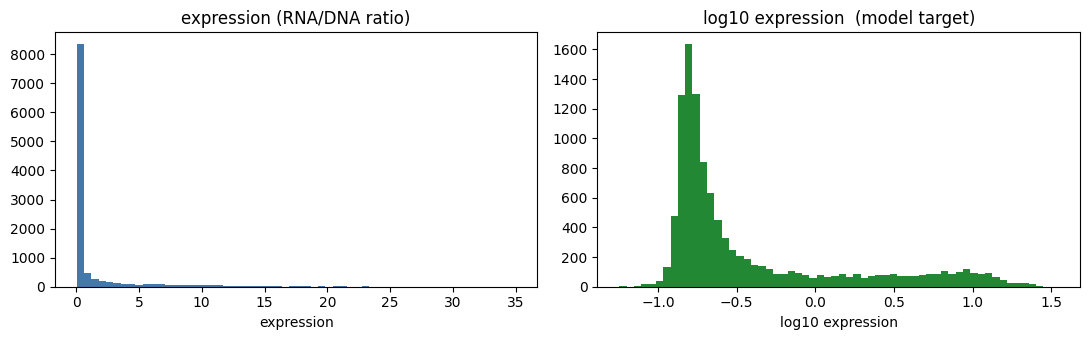

In [5]:
# Distribution of promoter strength (the regression target)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(df["expression"], bins=60, color="#4477AA")
ax[0].set_title("expression (RNA/DNA ratio)"); ax[0].set_xlabel("expression")
ax[1].hist(df["log_expression"], bins=60, color="#228833")
ax[1].set_title("log10 expression  (model target)"); ax[1].set_xlabel("log10 expression")
plt.tight_layout(); plt.show()

## 2. Turning DNA into numbers: the three featurizations

A model cannot read `"ACGT..."`. Each model family converts the sequence differently, and *those choices are exactly what make them succeed or fail* on the hard split. All live in `src/promoternet/features.py`.

### 2a. One-hot encoding (used by the CNN)
Each base becomes a 4-dim column (A, C, G, T). A 150 bp promoter becomes a `(4, 150)` image. **Position is preserved**, which is why the CNN can learn *where* a motif sits.

'ACGTAC' -> shape (4, 6)  (rows = A,C,G,T)
[[1 0 0 0 1 0]
 [0 1 0 0 0 1]
 [0 0 1 0 0 0]
 [0 0 0 1 0 0]]


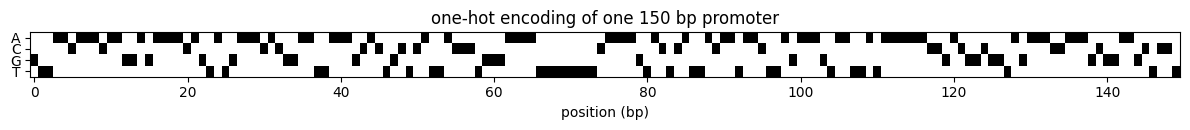

In [6]:
from promoternet.features import one_hot_encode

demo = "ACGTAC"
oh = one_hot_encode(demo)
print(f"'{demo}' -> shape {oh.shape}  (rows = A,C,G,T)")
print(oh.astype(int))

# Visualize a real promoter as a (4 x 150) image
real = df["sequence"].iloc[0]
fig, ax = plt.subplots(figsize=(12, 1.4))
ax.imshow(one_hot_encode(real), aspect="auto", cmap="Greys", interpolation="nearest")
ax.set_yticks(range(4)); ax.set_yticklabels(list("ACGT"))
ax.set_xlabel("position (bp)"); ax.set_title("one-hot encoding of one 150 bp promoter")
plt.tight_layout(); plt.show()

### 2b. k-mer counts (used by the XGBoost baseline)
Count every length-4, 5 and 6 substring. There are 4^4 + 4^5 + 4^6 = **4,160** possible k-mers. This is a *bag of words*: it knows which short motifs are **present** but throws away **where** they are. Hold that thought, it is the model's downfall.

In [7]:
from promoternet.features import kmer_counts, kmer_feature_matrix_multi, all_kmers

print("k-mer counts of 'ACGTACGT' (k=4):", kmer_counts("ACGTACGT", 4))
print("vocabulary sizes:", {k: len(all_kmers(k)) for k in (4, 5, 6)},
      "-> total", sum(len(all_kmers(k)) for k in (4, 5, 6)), "features")

X_kmer_demo = kmer_feature_matrix_multi(df["sequence"].iloc[:5].tolist(), (4, 5, 6))
print("feature matrix for 5 sequences:", X_kmer_demo.shape)

k-mer counts of 'ACGTACGT' (k=4): {'ACGT': 2, 'CGTA': 1, 'GTAC': 1, 'TACG': 1}
vocabulary sizes: {4: 256, 5: 1024, 6: 4096} -> total 5376 features
feature matrix for 5 sequences: (5, 5376)


### 2c. PWM motif scores (the mechanistic baseline)
A **Position Weight Matrix** is decades of bacterial genetics written down: how well does the best window in the sequence match the canonical `-10` (`TATAAT`) and `-35` (`TTGACA`) boxes? We slide each PWM along the sequence and keep the best score plus position, giving just **4 features** that feed a Ridge regression.

In [8]:
from promoternet.features import SIGMA70_MINUS_10_PWM, SIGMA70_MINUS_35_PWM, best_pwm_score, pwm_features

print("-10 PWM shape (4 x 6):"); print(SIGMA70_MINUS_10_PWM.round(2))
s10, p10 = best_pwm_score(real, SIGMA70_MINUS_10_PWM)
s35, p35 = best_pwm_score(real, SIGMA70_MINUS_35_PWM)
print(f"\nBest -10 match in promoter[0]: score {s10:+.2f} at position {p10}")
print(f"Best -35 match in promoter[0]: score {s35:+.2f} at position {p35}")
print("\npwm_features(first 3) -> [-10 score, -10 pos, -35 score, -35 pos]:")
print(pwm_features(df['sequence'].iloc[:3].tolist()).round(2))

-10 PWM shape (4 x 6):
[[0.05 0.85 0.05 0.85 0.85 0.05]
 [0.85 0.05 0.05 0.05 0.05 0.05]
 [0.05 0.05 0.05 0.05 0.05 0.05]
 [0.05 0.05 0.85 0.05 0.05 0.85]]

Best -10 match in promoter[0]: score +2.45 at position 20
Best -35 match in promoter[0]: score +6.51 at position 1

pwm_features(first 3) -> [-10 score, -10 pos, -35 score, -35 pos]:
[[ 2.45 20.    6.51  1.  ]
 [ 2.45 14.    2.45 70.  ]
 [ 2.45 47.    2.45  0.  ]]


## 3. The splits: the heart of the experiment

A **random** 80/10/10 split lets a model see, during training, examples of every part it will be tested on. That flatters memorization.

A **leave-element-out** split holds out *an entire part class*, so the model is tested only on promoters built from a `-10` (or spacer) it has **never seen**. This is the generalization question: can it predict for a new part? (`leave_element_out_split` in `data.py`.)

In [9]:
from promoternet.data import random_split, leave_element_out_split

rand = random_split(df, val_frac=0.1, test_frac=0.1, seed=42)
spacer = leave_element_out_split(df, element_col="spacer", val_frac=0.1, seed=42)
m10 = leave_element_out_split(df, element_col="m10_pattern", val_frac=0.1, seed=42)

for name, s in [("random 80/10/10", rand), ("leave-spacer-out", spacer), ("leave-m10-out", m10)]:
    extra = f"   held-out class: {s['holdout_value']!r}" if "holdout_value" in s else ""
    print(f"{name:18s} train={len(s['train']):>5,d}  val={len(s['val']):>4,d}  test={len(s['test']):>5,d}{extra}")

# Sanity check: the held-out -10 class truly never appears in training
held = m10["holdout_value"]
print(f"\nLeak check: held-out -10 '{held}' appears in train set "
      f"{(m10['train']['m10_pattern'] == held).sum()} times (should be 0)")

random 80/10/10    train=8,718  val=1,090  test=1,090
leave-spacer-out   train=8,491  val= 944  test=1,463   held-out class: 'ECK125136938'
leave-m10-out      train=8,570  val= 952  test=1,376   held-out class: '7T->A'

Leak check: held-out -10 '7T->A' appears in train set 0 times (should be 0)


## 4. The baselines, live: watch the k-mer trap spring

We fit the PWM and k-mer+XGBoost baselines on **two** regimes and compare. Watch the k-mer model's R2 on the random split versus leave-m10-out. (About 1 to 2 minutes: building 4,160-dim k-mer features plus training 600 boosted trees.)

In [10]:
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from promoternet.eval import regression_metrics

def fit_pwm(tr):
    return Ridge(alpha=1.0).fit(pwm_features(tr["sequence"].tolist()), tr["log_expression"].to_numpy())

def fit_kmer(tr, va):
    Xtr = kmer_feature_matrix_multi(tr["sequence"].tolist(), (4,5,6))
    Xva = kmer_feature_matrix_multi(va["sequence"].tolist(), (4,5,6))
    m = XGBRegressor(n_estimators=600, max_depth=7, learning_rate=0.05, subsample=0.85,
                     colsample_bytree=0.6, tree_method="hist", early_stopping_rounds=30, n_jobs=-1)
    m.fit(Xtr, tr["log_expression"].to_numpy(), eval_set=[(Xva, va["log_expression"].to_numpy())], verbose=False)
    return m

rows = []
for name, s in [("random", rand), ("leave-m10-out", m10)]:
    pwm_m = fit_pwm(s["train"])
    pwm_pred = pwm_m.predict(pwm_features(s["test"]["sequence"].tolist()))
    pwm_r2 = regression_metrics(s["test"]["log_expression"].to_numpy(), pwm_pred).r2

    kmer_m = fit_kmer(s["train"], s["val"])
    kmer_pred = kmer_m.predict(kmer_feature_matrix_multi(s["test"]["sequence"].tolist(), (4,5,6)))
    km = regression_metrics(s["test"]["log_expression"].to_numpy(), kmer_pred)
    rows.append({"split": name, "PWM R2": round(pwm_r2,3), "k-mer R2": round(km.r2,3), "k-mer Spearman": round(km.spearman,3)})

pd.DataFrame(rows)

,split,PWM R2,k-mer R2,k-mer Spearman
0,random,0.185,0.956,0.828
1,leave-m10-out,0.131,0.209,0.698


Notice: the k-mer model is near-perfect on the random split but **falls off a cliff** on leave-m10-out. It never learned sigma70 grammar. It learned *"this -10 sequence tends to be strong"*, which is useless for a `-10` it has not seen.

## 5. The CNN, live: positional grammar survives

The CNN (`PromoterCNN`, `src/promoternet/models.py`) is a DeepBind/Basset-style 1D conv net (about 130k params). Each conv filter is a *learnable motif scanner*; max-pooling asks "did this pattern appear **anywhere**?", keeping the position-awareness the k-mer model discarded. We train it on the same two splits.

In [11]:
import torch
from promoternet.models import PromoterCNN
from promoternet.train import TrainConfig, train_cnn, predict

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)
cfg = TrainConfig(epochs=40, batch_size=128, lr=1e-3, patience=6, seq_length=150, device=device)

cnn_rows = []
for name, s in [("random", rand), ("leave-m10-out", m10)]:
    torch.manual_seed(42); np.random.seed(42)
    model = PromoterCNN(seq_len=150)
    model, hist = train_cnn(model, s["train"], s["val"], config=cfg)
    pred = predict(model, s["test"], seq_length=150, device=device)
    m = regression_metrics(s["test"]["log_expression"].to_numpy(), pred)
    cnn_rows.append({"split": name, "epochs": len(hist["train_mse"]), "CNN R2": round(m.r2,3),
                     "CNN Spearman": round(m.spearman,3)})
    print(f"  {name:14s} trained {len(hist['train_mse'])} epochs -> {m.as_row()}")

pd.DataFrame(cnn_rows)

device: cuda


  random         trained 38 epochs -> n=1,090  R2=+0.9498  Pearson=+0.9775  Spearman=+0.8020  MSE=0.0161  MAE=0.0939


  leave-m10-out  trained 17 epochs -> n=1,376  R2=+0.6791  Pearson=+0.8402  Spearman=+0.8444  MSE=0.1229  MAE=0.2450


,split,epochs,CNN R2,CNN Spearman
0,random,38,0.950,0.802
1,leave-m10-out,17,0.679,0.844


The CNN holds a strong R2 on leave-m10-out where the k-mer model collapsed. (Exact numbers vary slightly run to run; the published run scored R2 around 0.67 and Spearman around 0.84.)

## 6. The full benchmark (all 4 models, all 3 splits)

Re-training DNABERT-6 live takes 7 to 40 minutes per split, so here we load the committed results so you see the complete picture including the foundation model.

In [12]:
def load_json(p): return json.loads((REPO / "reports" / p).read_text())
base = load_json("baselines_results.json"); cnn = load_json("cnn_results.json"); nt = load_json("nt_results.json")

splits = ["random_8_1_1", "leave_spacer_out", "leave_m10_out"]
nice = {"random_8_1_1": "Random 80/10/10", "leave_spacer_out": "Leave-spacer-out", "leave_m10_out": "Leave-m10-out"}
def r2(d, sp, key): return d[sp][key]["r2"]

table = pd.DataFrame({
    "Split": [nice[s] for s in splits],
    "PWM":        [r2(base, s, "pwm") for s in splits],
    "k-mer XGB":  [r2(base, s, "kmer_xgb") for s in splits],
    "CNN":        [r2(cnn, s, "cnn") for s in splits],
    "DNABERT-6":  [r2(nt, s, "nt") for s in splits],
})
display(table.style.format({"PWM":"{:.2f}","k-mer XGB":"{:.2f}","CNN":"{:.2f}","DNABERT-6":"{:.2f}"})
        .set_caption("Test R2 on Urtecho 2019"))

,Split,PWM,k-mer XGB,CNN,DNABERT-6
0,Random 80/10/10,0.18,0.96,0.95,0.95
1,Leave-spacer-out,0.23,0.85,0.87,0.87
2,Leave-m10-out,0.13,0.23,0.67,0.12


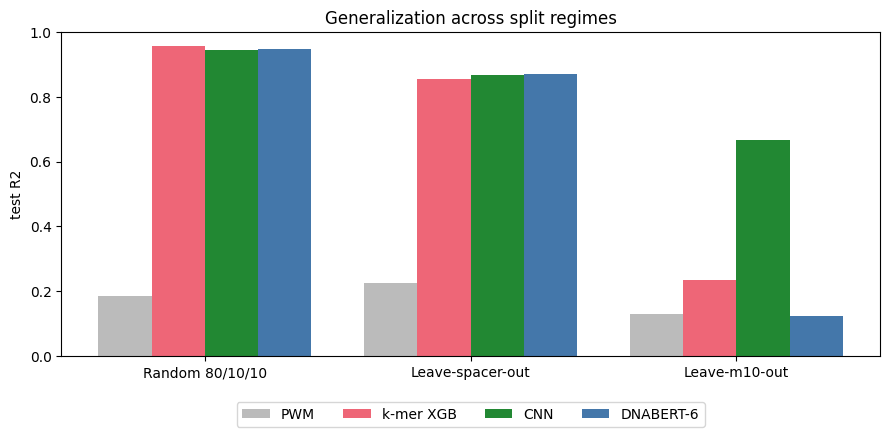

In [13]:
# Headline figure: everyone is great on random; only the CNN survives leave-m10-out
models = ["PWM", "k-mer XGB", "CNN", "DNABERT-6"]
colors = ["#BBBBBB", "#EE6677", "#228833", "#4477AA"]
x = np.arange(len(splits)); w = 0.2
fig, ax = plt.subplots(figsize=(9, 4.5))
for i, mdl in enumerate(models):
    ax.bar(x + (i-1.5)*w, table[mdl], w, label=mdl, color=colors[i])
ax.set_xticks(x); ax.set_xticklabels([nice[s] for s in splits])
ax.set_ylabel("test R2"); ax.set_ylim(0, 1.0); ax.axhline(0, color="k", lw=0.5)
ax.set_title("Generalization across split regimes"); ax.legend(ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.tight_layout(); plt.show()

## 7. Interpretability: the CNN rediscovered biology on its own

Two checks (`src/promoternet/interpret.py`, results in `reports/saliency_summary.json`):
1. **Saliency**: where does the trained CNN *look*? Gradient importance concentrates exactly at the `-35` and `-10` regions of the library design.
2. **Filter motifs**: do the first-layer conv filters match the textbook boxes? Several align with `TATAAT` / `TTGACA` at cosine above 0.8, with no supervision telling them to.

In [14]:
sal = load_json("saliency_summary.json")
print("Top attended positions (0-indexed in the 150 bp promoter):", sal["top_attended_positions"])
print("  -> cluster around the -35 box (about 87 to 89) and -10 box (about 108 to 113)\n")
print("First-layer filters matching the canonical sigma70 motifs:")
for box, hits in sal["motif_matches"].items():
    best = hits[0]
    print(f"  {box:18s} best = filter {best['filter']:>3d}  (cosine {best['score']:.2f} vs consensus)")

Top attended positions (0-indexed in the 150 bp promoter): [87, 89, 108, 109, 113]
  -> cluster around the -35 box (about 87 to 89) and -10 box (about 108 to 113)

First-layer filters matching the canonical sigma70 motifs:
  -10 box (TATAAT)   best = filter  55  (cosine 0.91 vs consensus)
  -35 box (TTGACA)   best = filter  37  (cosine 0.82 vs consensus)


generalization_bar.png


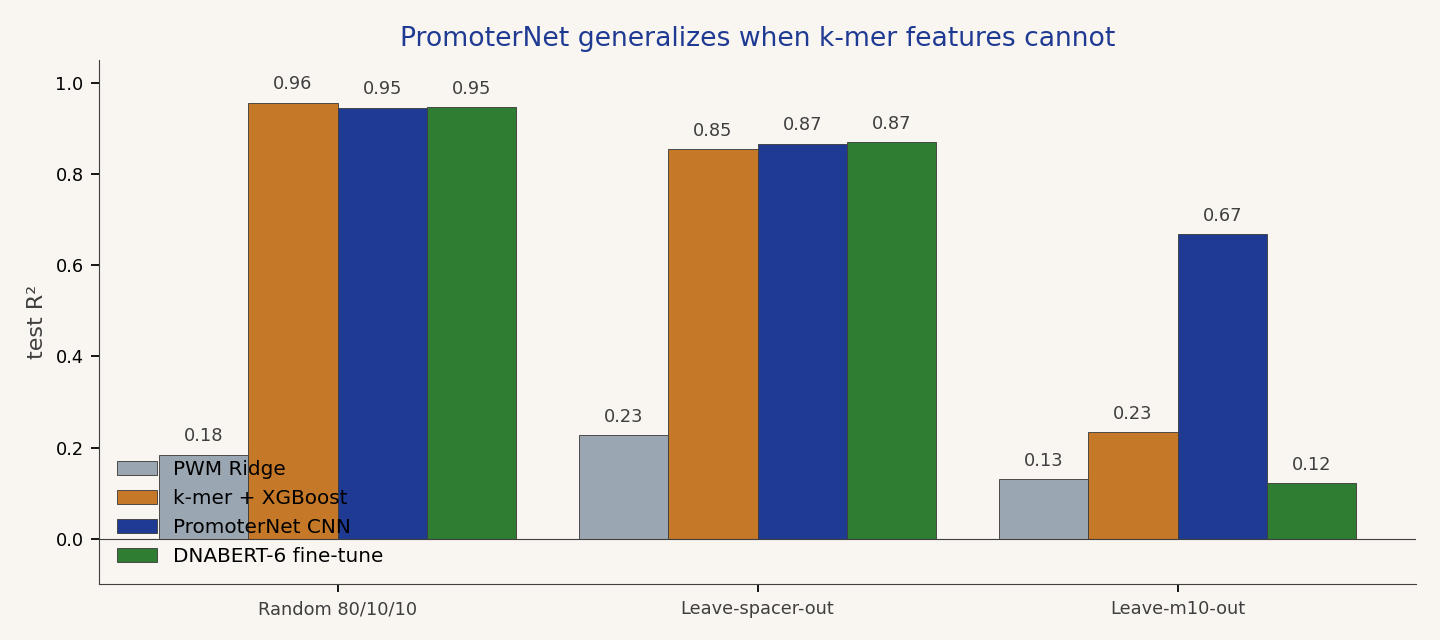

motif_logos.png


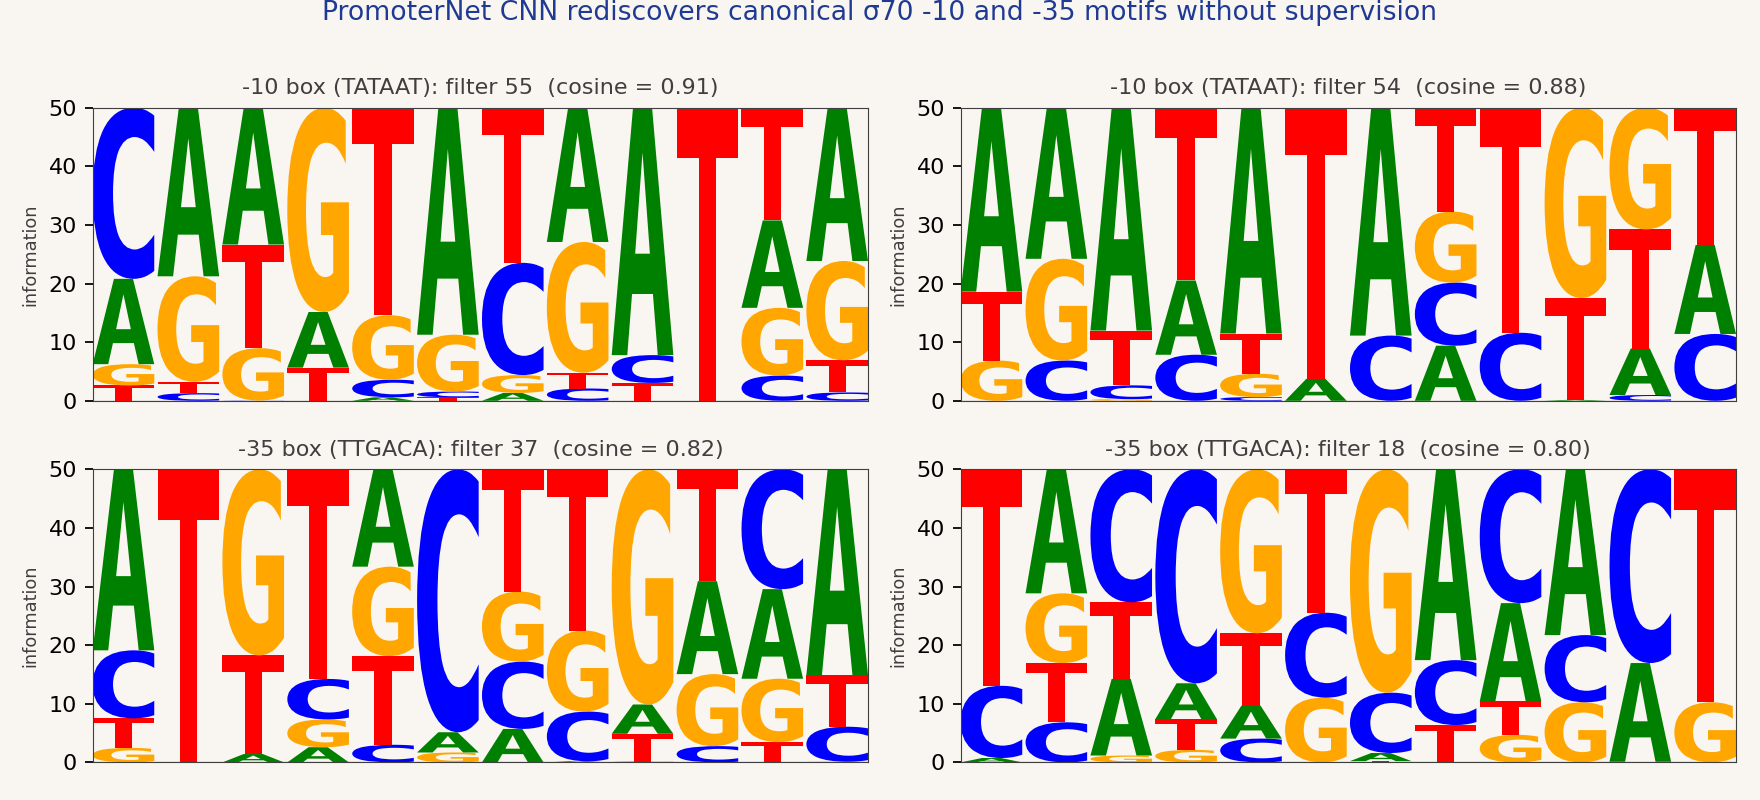

saliency_position_importance.png


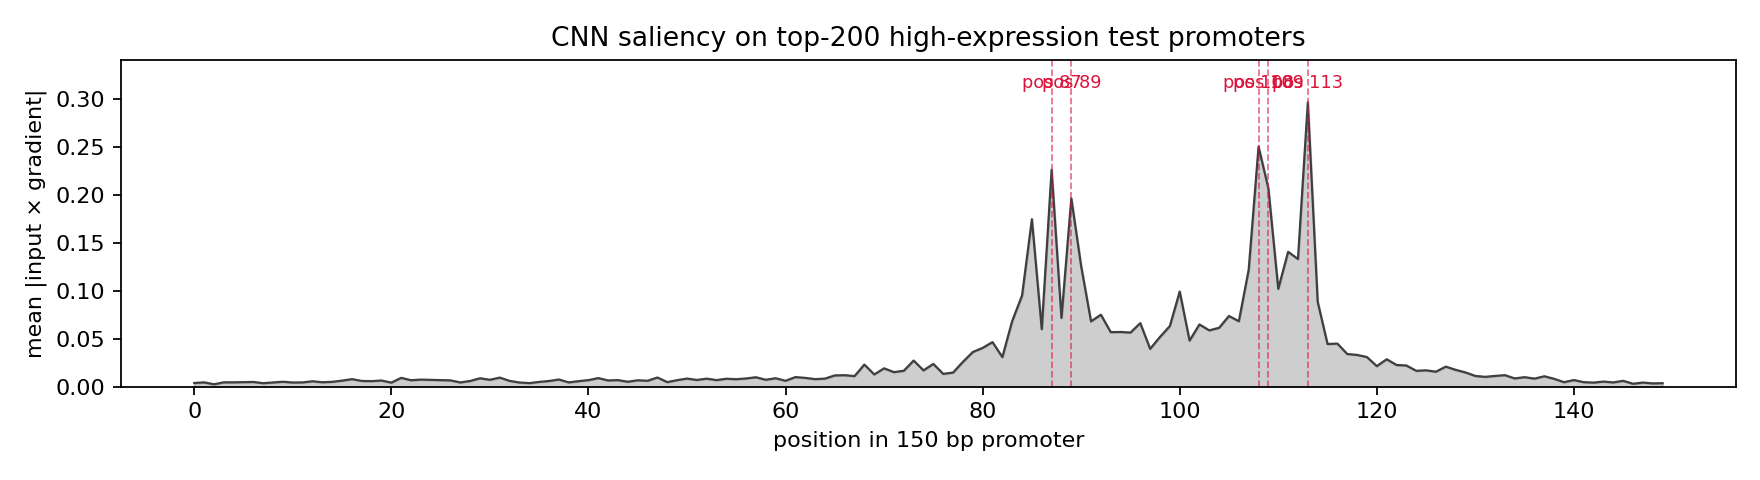

In [15]:
# Show the pre-rendered figures committed in reports/figures/
from IPython.display import Image, display
figdir = REPO / "reports" / "figures"
for fn in ["generalization_bar.png", "motif_logos.png", "saliency_position_importance.png"]:
    p = figdir / fn
    if p.exists():
        print(fn); display(Image(filename=str(p)))

## 8. What is DNABERT-6, and how was it fine-tuned?

**DNABERT-6** is a **BERT transformer pretrained on genomic DNA** (Ji et al. 2021, about 89M params). The "6" means it reads DNA as overlapping **6-mers**: `ATGCGT TGCGTA GCGTAC ...`, each 6-mer being one vocabulary token, just like words in a sentence. It was pretrained by *masking* random 6-mers and predicting them from context, learning general "DNA grammar."

**Fine-tuning here** (`src/promoternet/nt_model.py`): load the pretrained `BertModel`, attach a small regression head (mean-pool token embeddings, then Linear, GELU, Linear, to 1 value), and train end-to-end with MSE loss, AdamW (lr 3e-5), batch 16, fp16 mixed precision, gradient clipping, early stopping. About 7 to 40 minutes per split on an 8 GB GPU.

**Result interpretation:** it ranks promoters well (Spearman 0.73 on leave-m10-out) but its absolute R2 collapses to 0.12. The pretrained priors do not transfer cleanly to *E. coli* sigma70 context. Foundation model for ranking; small purpose-built model for calibration.

> Naming gotcha: the class is called `NucleotideTransformerRegressor` (a leftover from a scrapped Nucleotide-Transformer plan) but it actually loads `zhihan1996/DNA_bert_6`. It really is DNABERT-6.

To fine-tune it yourself: `python scripts/train_dnabert.py` (downloads the pretrained weights on first run).

## 9. Takeaways

- **Random-split accuracy is a vanity metric for design.** Hold out a whole part class and the picture changes completely.
- **Representation determines generalization.** k-mer counts (position-blind) memorize; the CNN (position-aware) learns grammar.
- **Foundation is not automatically best.** DNABERT-6 is great at ranking but mis-calibrated out-of-distribution; a 130k-param CNN trained on the right data wins where it counts.
- **The model learned real biology.** sigma70 boxes emerged in its filters unsupervised, so its predictions rest on mechanism, not artifacts.

**One-line summary:** set up the right held-out evaluation first, then choose the smallest model that survives it.